# BasisAE demo

This notebook builds a small synthetic movie cube and fits the `comicsnet.BasisAE` background model with the sparse-mask loop.

The synthetic cube contains a smooth time-variable background plus a moving compact source.  The model sees one complete detector frame per optimization step and reconstructs each frame as a linear combination of detector-fixed basis images.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import jax.numpy as jnp

from comicsnet import Config, BasisAE, fit

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

The array shape is `(time, y, x)`.  The size is intentionally small so
that the notebook runs quickly on CPU.

In [2]:
key = jax.random.PRNGKey(0)
nt, ny, nx = 64, 32, 32


def gaussian2d(y, x, y0, x0, sigma):
    radius2 = (y - y0) ** 2 + (x - x0) ** 2
    return jnp.exp(-0.5 * radius2 / sigma ** 2)


def background(t, y, x, fy, fx):
    spatial = 0.6 * x + 0.4 * y + 100.0 * jnp.sin(fy * y + fx * x)
    temporal = 100.0 * jnp.sin(2.0 * jnp.pi * t / nt)
    return 5000 + spatial + temporal


t = jnp.arange(nt, dtype=jnp.float32)[:, None, None]
y = jnp.arange(ny, dtype=jnp.float32)[None, :, None]
x = jnp.arange(nx, dtype=jnp.float32)[None, None, :]

scan_y = 2.0 + 0.45 * jnp.arange(nt, dtype=jnp.float32)
scan_x = 10.0 + 0.15 * jnp.arange(nt, dtype=jnp.float32)
frames = []

for frame_index in range(nt):
    source = 15.0 * gaussian2d(
        y[0],
        x[0],
        scan_y[frame_index],
        scan_x[frame_index],
        2.0,
    )
    b = background(
        t[frame_index],
        y[0],
        x[0],
        fy=0.04,
        fx=0.06,
    )
    frames.append(source + b)

ground_truth = jnp.stack(frames, axis=0)
noise = 1.0 * jax.random.normal(key, (nt, ny, nx))
cube = ground_truth + noise

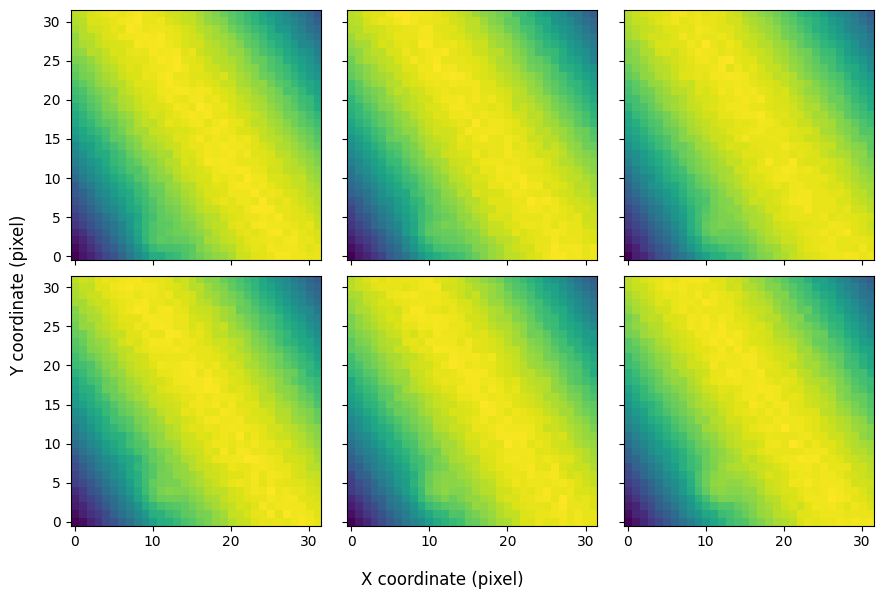

In [3]:
fig, axes = plt.subplots(
    2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
    ax.imshow(cube[n])

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit BasisAE

The model learns detector-fixed basis images and frame-wise
coefficients.


In [4]:
config = Config(
    outer_steps=100,
    inner_steps=200,
    learning_rate=1.0e-4,
    beta=1.0e-4,
    threshold_sigma=2.0,
    seed=1,
)

model_key = jax.random.PRNGKey(2)
model = BasisAE(
    frame_shape=(ny, nx),
    basis_dim=3,
    hidden_dim=4,
    latent_dim=8,
    key=model_key,
)

result = fit(model, cube, config=config)

The trace of the loss function is illustrated below. The loss is computed on the full cube, but the model sees only one frame per optimization step.

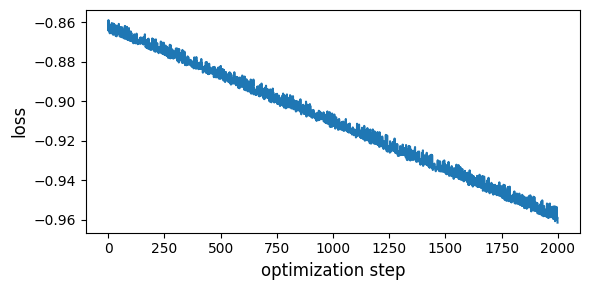

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-2000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

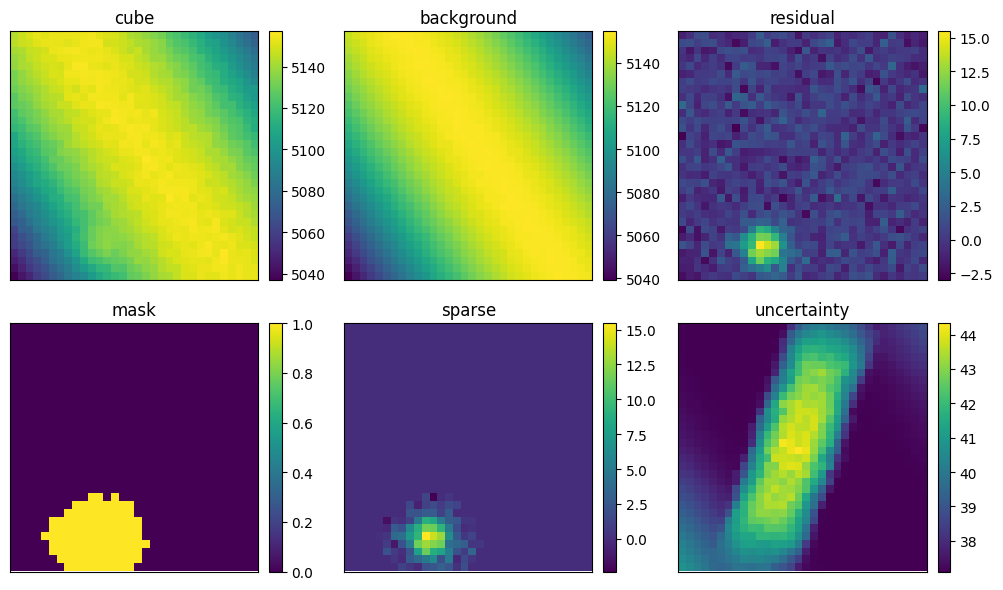

In [6]:
frame_index = 4

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
    ('cube', cube[frame_index]),
    ('background', result.background[frame_index]),
    ('residual', result.residual[frame_index]),
    ('mask', result.mask[frame_index]),
    ('sparse', result.sparse[frame_index]),
    ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
    handle = axis.imshow(image, origin='lower', cmap='viridis')
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()